In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install evaluate

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix, classification_report

from datasets import load_dataset
from collections import Counter

import numpy as np
import seaborn as sns
import pandas as pd
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import kagglehub, zipfile, os

from transformers import BertConfig, BertModel, BertTokenizerFast, BertForSequenceClassification, TrainingArguments, Trainer, get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup

"""
import kagglehub, zipfile, os
import pandas as pd
import numpy as np
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn.model_selection import train_test_split

from transformers import BertConfig, BertModel, BertTokenizerFast, BertForSequenceClassification, TrainingArguments, Trainer, get_linear_schedule_with_warmup
"""

'\nimport kagglehub, zipfile, os\nimport pandas as pd\nimport numpy as np\nimport random\n\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nfrom torch.utils.data import Dataset, DataLoader\nfrom sklearn.metrics import precision_recall_fscore_support, accuracy_score\nfrom sklearn.model_selection import train_test_split\n\nfrom transformers import BertConfig, BertModel, BertTokenizerFast, BertForSequenceClassification, TrainingArguments, Trainer, get_linear_schedule_with_warmup\n'

In [ ]:
torch.cuda.empty_cache()

In [ ]:
# Download latest version
path = kagglehub.dataset_download("blackmoon/russian-language-toxic-comments")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/russian-language-toxic-comments


In [ ]:
def set_random_seed(seed):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # <- add this line
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_random_seed(224)

In [ ]:
data = pd.read_csv('/root/.cache/kagglehub/datasets/blackmoon/russian-language-toxic-comments/versions/1/labeled.csv')

In [ ]:
ds_train = data[0:10000]
ds_val = data[10000:12000]
ds_test = data[12000:]

ds_train = ds_train.reset_index(drop=True)
ds_val = ds_val.reset_index(drop=True)
ds_test = ds_test.reset_index(drop=True)

In [ ]:
def parse_dataset(filepath):
    texts, slots, classes = [], [], []
    with open(filepath, 'r', encoding='utf-8') as file:
        current_text, current_slots, current_classes = [], [], []
        text_id = 0
        for line in file:
            line = line.strip()
            if line.startswith('# sent_id'):
              c = line.split()[3]
              text, sent = c.split('_')
              if text_id != int(text):
                texts.append(current_text)
                slots.append(current_slots)
                classes.append(current_classes)
                text_id = int(text)
                current_text, current_slots, current_classes = [], [], []
            elif line.startswith('# text'):
              continue
            elif not line:  # конец предложения
              continue
            else:
                l = line.split('\t')
                current_text.append(l[1])
                current_classes.append(l[-1])
                current_slots.append(l[-2])
        # добавим последнее предложение на случай, если файл не заканчивался на пустую строчку
        if current_text:
          texts.append(current_text)
          slots.append(current_slots)
          classes.append(current_classes)
    return texts, slots, classes

In [ ]:
from collections import defaultdict

def extract_classes_and_slots(filepath):
    classes = set()
    slots = set()

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            fields = line.split('\t')
            if len(fields) < 11:
                continue
            class_field = fields[11]
            slot_field = fields[10]
            #if class_field and class_field != '_':
            classes.add(class_field)
            #if slot_field and slot_field != '_':
            slots.add(slot_field)


    classes = sorted(classes)
    slots = sorted(slots)
    classes.append('PAD') # паддинга нет в датасете, но будет в текстах, надо включить
    slots.append('PAD')

    class2idx = {cls: idx for idx, cls in enumerate(classes)}
    idx2class = {idx: cls for cls, idx in class2idx.items()}

    slot2idx = {slot: idx for idx, slot in enumerate(slots)}
    idx2slot = {idx: slot for slot, idx in slot2idx.items()}

    return {
        'classes': classes,
        'slots': slots,
        'class2idx': class2idx,
        'idx2class': idx2class,
        'slot2idx': slot2idx,
        'idx2slot': idx2slot
    }

In [ ]:
class SemDataset(Dataset):
    def __init__(self, texts, labels, slots, classes, slot2id, class2id, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.slots = slots # слоты и классы так же
        self.classes = classes
        self.slot2id = slot2id
        self.class2id = class2id
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self):
        return len(self.texts)

    def align_tokens_and_labels(self, tokens, slots, classes):
        # тут нам надо сделать так, чтобы слоты и классы были правильно приписаны сабтокенам, на которые поделил токенайзер
        # будем приписывать всем сабтокенам, которые относятся к одному слову в конллу одинаковые слоты и классы
        word_ids = self.tokenizer.convert_tokens_to_ids(tokens)  # Индексы токенов
        aligned_slots = []
        aligned_classes = []

        current_word_idx = 0
        for word in word_ids:
            # Получаем текущий токен из разметки
            current_word = tokens[current_word_idx]

            # Получаем количество токенов для текущего слова из разметки
            original_word_token_count = len(self.tokenizer.tokenize(current_word))

            # Присваиваем всем токенам этого слова одинаковый тег
            for _ in range(original_word_token_count):
                aligned_slots.append(slots[current_word_idx])
                aligned_classes.append(classes[current_word_idx])

            # Переходим к следующему слову в разметке
            current_word_idx += 1

        return aligned_slots, aligned_classes

    def slice_token(self, index):
        start, stop, step = index.indices(len(self.texts))
        result = []
        for i in range(start, stop, step):
            tokens = self.texts[i]
            classes = self.classes[i]
            slots = self.slots[i]
            label = self.labels[i]
            encoding = self.tokenizer(
                            tokens,
                            is_split_into_words=True,
                            padding='max_length',
                            truncation=True,
                            max_length=self.max_length,
                            return_tensors='pt'
                        )
            slots, classes = self.align_tokens_and_labels(tokens, slots, classes)

            pad_len = self.max_length - len(slots)
            if pad_len > 0:
                for i in range(pad_len):
                    slots.append('PAD')
                    classes.append('PAD')
            else:
                slots = slots[:self.max_length]
                classes = classes[:self.max_length]

            slots = [self.slot2id[slot] for slot in slots]
            classes = [self.class2id[cls] for cls in classes]
            slots = torch.tensor(slots, dtype=torch.long)
            classes = torch.tensor(classes, dtype=torch.long)

            encoding["slots"] = slots
            encoding["classes"] = classes
            encoding["label"] = torch.tensor(label, dtype=torch.long)
            encoding["input_ids"] = torch.squeeze(encoding["input_ids"], 0)
            encoding["token_type_ids"] = torch.squeeze(encoding["token_type_ids"], 0)
            encoding["attention_mask"] = torch.squeeze(encoding["attention_mask"], 0)

            result.append({key: torch.tensor(val) for key, val in encoding.items()})

        return result

    def __getitem__(self, idx):

        if isinstance(idx, slice):
            # Обработка среза
            return self.slice_token(idx)
        elif isinstance(idx, int):
            tokens = self.texts[idx]
            classes = self.classes[idx]
            slots = self.slots[idx]
            label = self.labels[idx]
            # токенизируем
            encoding = self.tokenizer(
                tokens,
                padding='max_length',
                is_split_into_words=True,
                truncation = True,
                max_length = self.max_length,
                return_tensors = 'pt'
            )
            slots, classes = self.align_tokens_and_labels(tokens, slots, classes)

            pad_len = self.max_length - len(slots)
            if pad_len > 0:
                for i in range(pad_len):
                    slots.append('PAD')
                    classes.append('PAD')
            else:
                slots = slots[:self.max_length]
                classes = classes[:self.max_length]

            slots = [self.slot2id[slot] for slot in slots]
            classes = [self.class2id[cls] for cls in classes]

            slots = torch.tensor(slots, dtype=torch.long)
            classes = torch.tensor(classes, dtype=torch.long)

            encoding["slots"] = slots
            encoding["classes"] = classes
            encoding["label"] = torch.tensor(label, dtype=torch.long)
            encoding["input_ids"] = torch.squeeze(encoding["input_ids"], 0)
            encoding["token_type_ids"] = torch.squeeze(encoding["token_type_ids"], 0)
            encoding["attention_mask"] = torch.squeeze(encoding["attention_mask"], 0)
            """
            item = {key: val.squeeze(0) for key, val in encoding.items()}  # Убираем batch dim
            item['labels'] = torch.tensor(tag, dtype=torch.long) # Без лишнего
            """
            return encoding

In [ ]:
tokenizer = BertTokenizerFast.from_pretrained('DeepPavlov/rubert-base-cased')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
texts, slots, classes = parse_dataset('/content/drive/MyDrive/Colab Notebooks/курсач/датасеты/токсичность/labeled_pred.conllu')

def create_dataloader_train(labels, tokenizer, slots2id, classes2id, batch_size=16, max_length=256):
    dataset = SemDataset(texts[:10000], labels, slots[:10000], classes[:10000], slots2id, classes2id, tokenizer, max_length=max_length)
    #little_dataset = dataset[0:1000]
    return DataLoader(dataset, batch_size=batch_size, shuffle=False) #shuffle=True

def create_dataloader_val(labels, tokenizer, slots2id, classes2id, batch_size=16, max_length=256):
    dataset = SemDataset(texts[10000:12000], labels, slots[10000:12000], classes[10000:12000], slots2id, classes2id, tokenizer, max_length=max_length)
    #little_dataset = dataset[0:300]
    return DataLoader(dataset, batch_size=batch_size, shuffle = False)

def create_dataloader_test(labels, tokenizer, slots2id, classes2id, batch_size=16, max_length=256):
    dataset = SemDataset(texts[12000:], labels, slots[12000:], classes[12000:], slots2id, classes2id, tokenizer, max_length=max_length)
    #little_dataset = dataset[0:300]
    return DataLoader(dataset, batch_size=batch_size, shuffle = False)

In [ ]:
extracted = extract_classes_and_slots('/content/drive/MyDrive/Colab Notebooks/курсач/датасеты/токсичность/labeled_pred.conllu')
train_dataloader = create_dataloader_train(ds_train['toxic'], tokenizer, extracted['slot2idx'], extracted['class2idx'], batch_size=16)
val_dataloader = create_dataloader_val(ds_val['toxic'], tokenizer, extracted['slot2idx'], extracted['class2idx'], batch_size=16)
test_dataloader = create_dataloader_val(ds_test['toxic'], tokenizer, extracted['slot2idx'], extracted['class2idx'], batch_size=16)

In [ ]:
next(iter(train_dataloader))

{'input_ids': tensor([[  101, 40449,  8523,  ...,     0,     0,     0],
         [  101, 38218,  9485,  ...,     0,     0,     0],
         [  101, 12000, 24650,  ...,     0,     0,     0],
         ...,
         [  101, 14395,  9582,  ...,     0,     0,     0],
         [  101, 22379,  1515,  ...,     0,     0,     0],
         [  101,   110,   196,  ...,     0,     0,     0]]),
 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]]),
 'slots': tensor([[ 70,  70,  70,  ..., 126, 126, 126],
         [122, 122, 125,  ..., 126, 126, 126],
         [ 70,  70,  90,  

In [ ]:
class BiLSTMPooling(nn.Module):
    def __init__(self, emb_dim, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_size,
            bidirectional=True,
            batch_first=True
        )

    def forward(self, token_embeddings):
        # token_embeddings: [batch_size, seq_len, emb_dim]
        lstm_out, _ = self.lstm(token_embeddings)  # [batch_size, seq_len, 2*hidden_size]
        return lstm_out.mean(dim=1)  # Mean pooling over sequence

In [ ]:
class SentimentClassifier(nn.Module):
  def __init__(self, num_labels, num_semantic_classes, num_semantic_slots, semantic_emb_dim=256, lstm_hidden_size=128):
  #def __init__(self, n_classes):
    super().__init__()
    self.bert = BertModel.from_pretrained("DeepPavlov/rubert-base-cased")
    self.drop = nn.Dropout(p=0.3)
    #self.out = nn.Linear(self.bert.config.hidden_size, n_classes)
    #self.loss_fct = nn.CrossEntropyLoss()

    self.semantic_class_embedding = nn.Embedding(num_semantic_classes, semantic_emb_dim)
    self.semantic_slot_embedding = nn.Embedding(num_semantic_slots, semantic_emb_dim)

    # BiLSTM для обработки семантических последовательностей
    self.semantic_lstm = BiLSTMPooling(emb_dim=semantic_emb_dim, hidden_size=lstm_hidden_size)

    # Классификатор — BERT + BiLSTM(class) + BiLSTM(slot)
    self.classifier = nn.Linear(self.bert.config.hidden_size + 2 * 2 * lstm_hidden_size, num_labels)

    #self.classifier = nn.Linear(self.bert.config.hidden_size + 2 * semantic_emb_dim, num_labels)

  def forward(self, input_ids=None, token_type_ids=None, attention_mask=None, slots=None, classes=None):
  #def forward(self, input_ids, attention_mask):
    _, pooled_output = self.bert(
      input_ids=input_ids,
      attention_mask=attention_mask,
      return_dict=False)

    mask = attention_mask.unsqueeze(-1).float()

    # Эмбеддинги семантики: предполагается, что slots и classes — (batch_size,)
    semantic_class_embeds = self.semantic_class_embedding(classes)  # (batch_size, sem_emb_dim)
    semantic_slot_embeds = self.semantic_slot_embedding(slots)      # (batch_size, sem_emb_dim)

    semantic_class_embeds = semantic_class_embeds * mask
    semantic_slot_embeds = semantic_slot_embeds * mask

    """
    # Сумма по токенам
    class_embeds_sum = semantic_class_embeds.sum(dim=1)  # (batch_size, sem_emb_dim)
    slot_embeds_sum =  semantic_slot_embeds.sum(dim=1)

    # Количество непаддинговых токенов
    lengths = mask.sum(dim=1).clamp(min=1e-6)  # (batch_size, 1)

    # Среднее
    class_embeds_avg = class_embeds_sum / lengths
    slot_embeds_avg = slot_embeds_sum / lengths

    # Dropout
    combined_output = torch.cat([pooled_output, class_embeds_avg, slot_embeds_avg], dim=-1)
    """

    class_summary = self.semantic_lstm(semantic_class_embeds)  # (batch_size, 2 * hidden_size)
    slot_summary = self.semantic_lstm(semantic_slot_embeds)    # (batch_size, 2 * hidden_size)

        # Объединяем
    combined = torch.cat([pooled_output, class_summary, slot_summary], dim=1)  # (batch_size, ...)

    #output = self.drop(pooled_output)

    return self.classifier(combined)

In [ ]:
num_labels = 2
num_semantic_classes = len(extracted['classes'])
num_semantic_slots = len(extracted['slots'])

model = SentimentClassifier(num_labels=num_labels,
    num_semantic_classes=num_semantic_classes,
    num_semantic_slots=num_semantic_slots)

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
EPOCHS = 3

#optimizer = AdamW(model.parameters(), lr=2e-5, correct_bias=False)
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5) #correct_bias=False
total_steps = len(train_dataloader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
  optimizer,
  num_warmup_steps=0,
  num_training_steps=total_steps
)

loss_fn = nn.CrossEntropyLoss().to(device)

In [ ]:
def train_epoch(
  model,
  data_loader,
  loss_fn,
  optimizer,
  device,
  scheduler,
  n_examples
):
  model = model.train()

  losses = []
  correct_predictions = 0
  all_preds = []
  all_labels = []


  for d in data_loader:
    input_ids = d["input_ids"].to(device)
    attention_mask = d["attention_mask"].to(device)
    targets = d["label"].to(device)
    slots = d['slots'].to(device)
    classes = d['classes'].to(device)

    outputs = model(
      input_ids=input_ids,
      attention_mask=attention_mask,
      slots=slots,
      classes=classes)

    #preds = torch.argmax(outputs, dim=1)
    loss = loss_fn(outputs, targets)

    all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
    all_labels.extend(targets.cpu().numpy())

    #correct_predictions += torch.sum(preds == targets)
    losses.append(loss.item())

    loss.backward()
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()

  precision, recall, f1, _ = precision_recall_fscore_support(
  all_labels, all_preds, average='binary', zero_division=0)
  acc = accuracy_score(all_labels, all_preds)
  print(confusion_matrix(all_labels, all_preds))

  return precision, recall, f1, acc, np.mean(losses)

In [ ]:
def eval_model(model, data_loader, loss_fn, device, n_examples):
  model = model.eval()

  losses = []
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for d in data_loader:
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["label"].to(device)
      slots = d['slots'].to(device)
      classes = d['classes'].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        slots=slots,
        classes=classes
      )

      loss = loss_fn(outputs, targets)

      all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
      all_labels.extend(targets.cpu().numpy())

      #correct_predictions += torch.sum(preds == targets)
      losses.append(loss.item())

  precision, recall, f1, _ = precision_recall_fscore_support(
  all_labels, all_preds, average='binary', zero_division=0)
  acc = accuracy_score(all_labels, all_preds)
  print(confusion_matrix(all_labels, all_preds))

  return precision, recall, f1, acc, np.mean(losses)

In [ ]:
%%time

history = defaultdict(list)
#best_accuracy = 0

for epoch in range(EPOCHS):

  print(f'Epoch {epoch + 1}/{EPOCHS}')
  print('-' * 10)

  train_precision, train_recall, train_f1, train_acc, train_loss = train_epoch(
    model,
    train_dataloader,
    loss_fn,
    optimizer,
    device,
    scheduler,
    len(ds_train)
  )

  print(f'Train loss {train_loss} train_acc {train_acc} train_precision {train_precision}, train_recall {train_recall}, train_f1 {train_f1}')

  val_precision, val_recall, val_f1, val_acc, val_loss = eval_model(
    model,
  val_dataloader,
    loss_fn,
    device,
    len(ds_val)
  )

  print(f'Val loss {val_loss} val_acc {val_acc} val_precision {val_precision}, val_recall {val_recall}, val_f1 {val_f1}')
  print()

  history['train_acc'].append(train_acc)
  history['train_loss'].append(train_loss)
  history['val_acc'].append(val_acc)
  history['val_loss'].append(val_loss)


  """
  if val_acc > best_accuracy:
    torch.save(model.state_dict(), 'best_model_state.bin')
    best_accuracy = val_metrics['accuracy']
  """

Epoch 1/3
----------
[[5539  868]
 [ 605 2988]]
Train loss 0.341234743951261 train_acc 0.8527 train_precision 0.774896265560166, train_recall 0.8316170331199555, train_f1 0.8022553362867499
[[1590   35]
 [  85  290]]
Val loss 0.15823889102041722 val_acc 0.94 val_precision 0.8923076923076924, val_recall 0.7733333333333333, val_f1 0.8285714285714286

Epoch 2/3
----------
[[5747  660]
 [ 288 3305]]
Train loss 0.23126914664283396 train_acc 0.9052 train_precision 0.8335435056746532, train_recall 0.9198441413860284, train_f1 0.8745699920613919
[[1597   28]
 [  79  296]]
Val loss 0.1975326260998845 val_acc 0.9465 val_precision 0.9135802469135802, val_recall 0.7893333333333333, val_f1 0.8469241773962805

Epoch 3/3
----------
[[5966  441]
 [ 204 3389]]
Train loss 0.17945210092440247 train_acc 0.9355 train_precision 0.8848563968668407, train_recall 0.9432229334817701, train_f1 0.9131079078539674
[[1594   31]
 [  79  296]]
Val loss 0.1894174136482179 val_acc 0.945 val_precision 0.9051987767584098

In [ ]:
from collections import Counter
labels = []

for batch in train_dataloader:
    #labels.extend(batch['label'].tolist())
    print(batch['slots'].shape, batch['classes'].shape)

#print(Counter(labels))

torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size

In [ ]:
history['train_acc'] = [score.to('cpu') for score in  history['train_acc']]
history['val_acc'] = [score.to('cpu') for score in  history['val_acc']]

AttributeError: 'float' object has no attribute 'to'

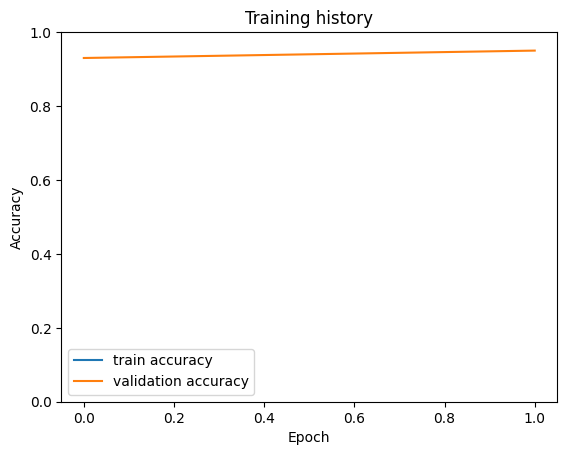

In [ ]:
plt.plot(history['train_acc'], label='train accuracy')
plt.plot(history['val_acc'], label='validation accuracy')

plt.title('Training history')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1]);

In [ ]:
test_precision, test_recall, test_f1, test_acc, test_loss = eval_model(
  model,
  test_dataloader,
  loss_fn,
  device,
  len(ds_test)
)

print(test_precision, test_recall, test_f1, test_acc, test_loss)

[[1207  234]
 [ 466   93]]
0.28440366972477066 0.16636851520572452 0.20993227990970656 0.65 1.6309122862108052


In [ ]:
def get_predictions(model, data_loader):
  model = model.eval()

  #review_texts = []
  predictions = []
  prediction_probs = []
  real_values = []

  with torch.no_grad():
    for d in data_loader:

      #texts = d["review_text"]
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["label"].to(device)
      slots = d['slots'].to(device)
      classes = d['classes'].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        slots=slots,
        classes=classes
      )
      preds = torch.argmax(outputs, dim=1)

      probs = F.softmax(outputs, dim=1)

      #review_texts.extend(texts)
      predictions.extend(preds)
      prediction_probs.extend(probs)
      real_values.extend(targets)

  predictions = torch.stack(predictions).cpu()
  prediction_probs = torch.stack(prediction_probs).cpu()
  real_values = torch.stack(real_values).cpu()
  return predictions, prediction_probs, real_values

In [ ]:
y_pred, y_pred_probs, y_test = get_predictions(model, test_dataloader)

In [ ]:
print(classification_report(y_test, y_pred, target_names=['0', '1']))

              precision    recall  f1-score   support

           0       0.72      0.84      0.78      1441
           1       0.28      0.17      0.21       559

    accuracy                           0.65      2000
   macro avg       0.50      0.50      0.49      2000
weighted avg       0.60      0.65      0.62      2000



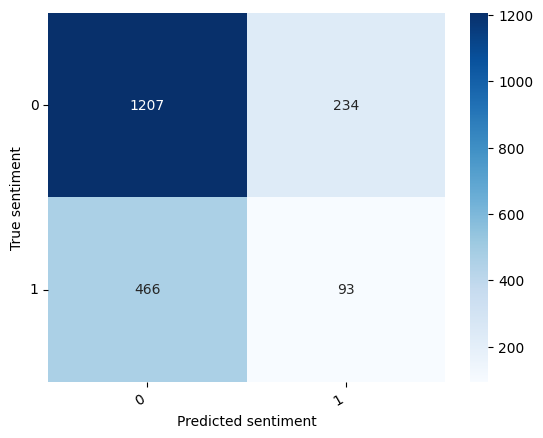

In [ ]:
def show_confusion_matrix(confusion_matrix):
  hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
  hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
  hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
  plt.ylabel('True sentiment')
  plt.xlabel('Predicted sentiment');

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=['0', '1'], columns=['0', '1'])
show_confusion_matrix(df_cm)



---

старое

In [ ]:
model = BertForSequenceClassification.from_pretrained('google-bert/bert-base-uncased', num_labels = 2)
model = model.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5, correct_bias=False)
training_args = TrainingArguments(
    output_dir='./results',          # Output directory
    eval_strategy="epoch",    # Evaluate after each epoch
    learning_rate=2e-5,             # Learning rate
    per_device_train_batch_size=32, # Batch size for training
    per_device_eval_batch_size=32,  # Batch size for evaluation
    num_train_epochs=3,             # Number of epochs
    weight_decay=0.01,              # Strength of weight decay
    logging_dir="./logs",           # Directory for storing logs
    logging_steps=10,               # что это такое?
    save_strategy="epoch",          # Save model after each epoch
    load_best_model_at_end=True,    # Load the best model after training
    metric_for_best_model="f1", # Use F1 score to choose the best model
    seed=RANDOM_SEED
)

/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [ ]:
def compute_metrics(p):
    predictions, labels = p
    # логиты в индексы
    predictions = predictions.argmax(axis=-1)

    # пихнем в метрику и получим результат
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_train,  # Training dataset
    eval_dataset=dataset_val,   # Evaluation dataset
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
    )


<ipython-input-16-15a526cef7f9>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# собственно обучение - автоматически делает логи
trainer.train()

# оценим модельку
eval_results = trainer.evaluate()
print(f"Evaluation Results: {eval_results}")

# Сохраним, что получилось
trainer.save_model("./ner_model")
#b5a31e3a762dc4fdbd905c7a205899ee8116917a

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: lizaolva123 (lizaolva123-rggu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.305300,0.380293,0.858530,0.780172,0.870192,0.707031
2,0.339300,0.316942,0.872399,0.820312,0.820312,0.820312
3,0.289800,0.324929,0.893204,0.843177,0.880851,0.808594


Evaluation Results: {'eval_loss': 0.32492873072624207, 'eval_accuracy': 0.8932038834951457, 'eval_f1': 0.8431771894093686, 'eval_precision': 0.8808510638297873, 'eval_recall': 0.80859375, 'eval_runtime': 23.2211, 'eval_samples_per_second': 31.049, 'eval_steps_per_second': 0.99, 'epoch': 3.0}


In [ ]:
def eval_model(model, data_loader, device):
  model = model.eval()

  all_preds = torch.tensor([], device=device)
  all_trues = torch.tensor([], device=device)

  with torch.no_grad():
    for d in data_loader:
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["labels"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )
      #print(outputs)
      preds = torch.argmax(outputs['logits'], axis=-1)
      all_preds = torch.cat((all_preds, preds), -1)
      all_trues = torch.cat((all_trues, targets), -1)

  precision, recall, f1, _ = precision_recall_fscore_support(all_trues.cpu(), all_preds.cpu(), average='macro')
  acc = accuracy_score(all_trues.cpu(), all_preds.cpu())
  return {
      'accuracy': acc,
      'f1': f1,
      'precision': precision,
      'recall': recall
  }

In [ ]:
test = eval_model(model, test_loader, device)

In [ ]:
test

{'accuracy': 0.8848821081830791,
 'f1': 0.8657798352386528,
 'precision': 0.879727720472075,
 'recall': 0.8554682742662283}

In [ ]:
precision, recall, f1, _ = precision_recall_fscore_support(torch.tensor(data['toxic']), torch.zeros(14412), average='macro')
acc = accuracy_score(torch.tensor(data['toxic']), torch.zeros(14412))
print({
      'accuracy': acc,
      'f1': f1,
      'precision': precision,
      'recall': recall})

{'accuracy': 0.6651401609769636, 'f1': 0.3994499541628469, 'precision': 0.3325700804884818, 'recall': 0.5}


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
